# Scratch Notebook

Scratch work for crystal_im_py github repository. Pasting in full functions to make sure code works before implementing in demo notebook. Working through holes in the existing functions.

In [1]:
import sys
import os

# Adds 'crystal_im_py' to the path so 'crystal_tools' is recognized as a package
sys.path.append(os.path.abspath(".."))

from crystal_tools.image_loading import load_images_from_folder
from crystal_tools.data_merging import calculate_channel_intensities, add_temp_data

In [2]:
# Apply initial functions to demo data

temps_list = ['075', '090', '105', '120', '135'] # enter temperatures using conventions of file names
folder_root = 'demo_data/batch_images/TOPA-1-' # enter filepath for batch image folders
temp_path = 'demo_data/temp_data/TOPA-1-' # enter filepath for temperature .csv data

time = 0.484 # enter time interval for each microscopy image (default is 0.484 s)

df_list = []
for temp in temps_list:
    # load images from folder
    images, files = load_images_from_folder(f'{folder_root}{temp}')
    df = calculate_channel_intensities(images, channels={'red':0, 'green': 1, 'blue': 2}, time_interval=time)

    # add temperature data
    temp_filename = f'{temp_path}{temp}.csv'
    add_temp_data(temp_filename, df, time)

    # add to df list for experiment
    df_list.append(df) # df_list stores all dataframes -- change this is loading multiple experiments of data

Path exists: demo_data/batch_images/TOPA-1-075
Found 200 .png files
Loaded 200 images
 
Processed 200 images
Time range: 0.00s to 96.32s

DataFrame shape: (200, 4)
Columns: ['time', 'mean_red', 'mean_green', 'mean_blue']
Path exists: demo_data/batch_images/TOPA-1-090
Found 200 .png files
Loaded 200 images
 
Processed 200 images
Time range: 0.00s to 96.32s

DataFrame shape: (200, 4)
Columns: ['time', 'mean_red', 'mean_green', 'mean_blue']
Path exists: demo_data/batch_images/TOPA-1-105
Found 200 .png files
Loaded 200 images
 
Processed 200 images
Time range: 0.00s to 96.32s

DataFrame shape: (200, 4)
Columns: ['time', 'mean_red', 'mean_green', 'mean_blue']
Path exists: demo_data/batch_images/TOPA-1-120
Found 200 .png files
Loaded 200 images
 
Processed 200 images
Time range: 0.00s to 96.32s

DataFrame shape: (200, 4)
Columns: ['time', 'mean_red', 'mean_green', 'mean_blue']
Path exists: demo_data/batch_images/TOPA-1-135
Found 200 .png files
Loaded 200 images
 
Processed 200 images
Time ra

In [3]:
df_list[0]

,time,mean_red,mean_green,mean_blue,temp
0,0.000,0.950077,2.732685,14.504665,31.90000
1,0.484,0.910141,2.764145,14.501770,31.99680
2,0.968,0.902554,2.752949,14.493965,32.09360
3,1.452,0.929981,2.736187,14.493752,32.19040
4,1.936,0.921055,2.755104,14.498417,32.28720
...,...,...,...,...,...
195,94.380,0.289673,2.801918,9.820339,72.63560
196,94.864,0.282146,2.777592,9.764610,72.93568
197,95.348,0.275070,2.796986,9.666454,73.23576
198,95.832,0.277229,2.771809,9.565598,73.53584


In [4]:
# load in initial image for baseline channel intensity values
from crystal_tools.imports import *

def load_init_image(filepath, init_channel='blue', final_channel='green'):
    """
    Load in initial image and extract initial and final channel intensities for alpha
    
    Parameters:
    -----------
    filepath : directory for initial image (.png format)
    init_channel: initial color channel for alpha parameter (i.e., at alpha=0, this is the dominant channel)
    final_channel: final color channel for alpha parameter (i.e., at alpha=1.0, this is the dominant channel)
    
    Returns:
    --------
    init_0: intensity of initial channel at t=0
    final_0: intensity of final channel at t=0
    """    
    
    # Read image
    image = ski.io.imread(filepath)

    # Extract mean intensity per channel
    red_mean   = np.mean(image[:, :, 0])
    green_mean = np.mean(image[:, :, 1])
    blue_mean  = np.mean(image[:, :, 2])

    if init_channel == 'red':
        init_0 = red_mean
    elif init_channel == 'green':
        init_0 = green_mean
    else: init_0 = blue_mean

    if final_channel == 'red':
        final_0 = red_mean
    elif final_channel == 'green':
        final_0 = green_mean
    else: final_0 = blue_mean
    
    print(f'Initial value for {init_channel} channel = {init_0:.4f}')
    print(f'Initial value for {final_channel} channel = {final_0:.4f}')

    return init_0, final_0

In [5]:
# Test load_init_image with demo data
filepath = 'demo_data/batch_images/TOPA-1-075/TOPA-1-075_b0v0t0z0c0-32x0-512y0-512.png'
init_0, final_0 = load_init_image(filepath, init_channel='blue', final_channel='green')

Initial value for blue channel = 14.5047
Initial value for green channel = 2.7327


In [7]:
# calculate alpha and q as a function of time
from crystal_tools.imports import *

def calculate_rxn_progress(df, init_0, final_0, exp_name, init_channel='blue', final_channel='green'):
    """
    Calculate alpha and reaction quotient q as a function of time
    
    Parameters:
    -----------
    df : dataframe of experiment image data (from image_loading.py and data_analysis.py)
    init_0: intensity of initial channel at t=0 (from load_init_image)
    final_0: intensity of final channel at t=0 (from load_init_image)
    exp_name: experiment name/temperature information (string)
    
    init_channel: initial color channel for alpha parameter (string)
    final_channel: final color channel for alpha parameter (string)
    
    Returns:
    --------
    df['alpha'] = normalized conversion ratio (scale from 0 to 1)
    df['q'] = reaction quotient (scale from 0 to infinity)
    """    

    # calculate alpha and q
    df['alpha'] = 1 - df[f'mean_{init_channel}']/df[f'mean_{final_channel}']*final_0/init_0
    df['q'] = df['alpha']/(1-df['alpha'])

    # create a plot of alpha w.r.t. time
    plt.plot(df['time'], df['alpha'])
    plt.xlabel('Time (s)')
    plt.ylabel('Conversion Ratio α')
    plt.title(f'Conversion Ratio vs. Time for {exp_name}')

    plt.show()

Initial value for blue channel = 14.5047
Initial value for green channel = 2.7327


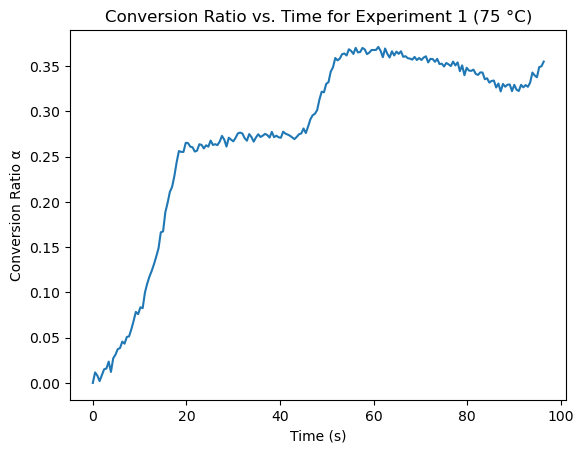

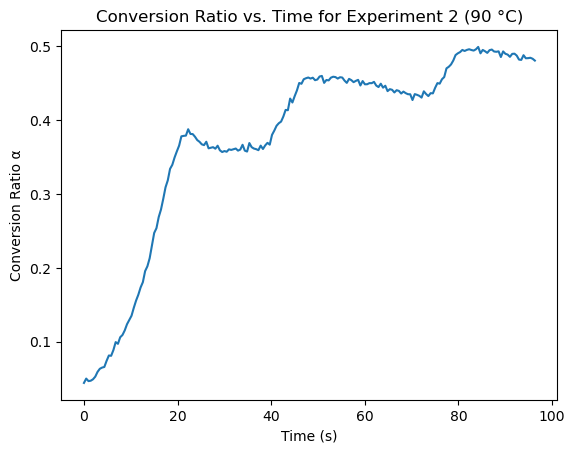

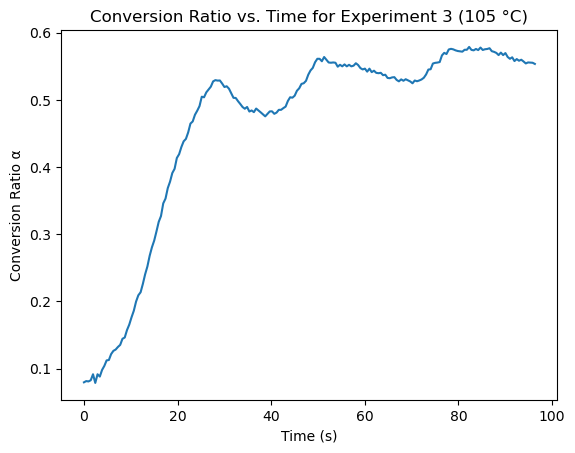

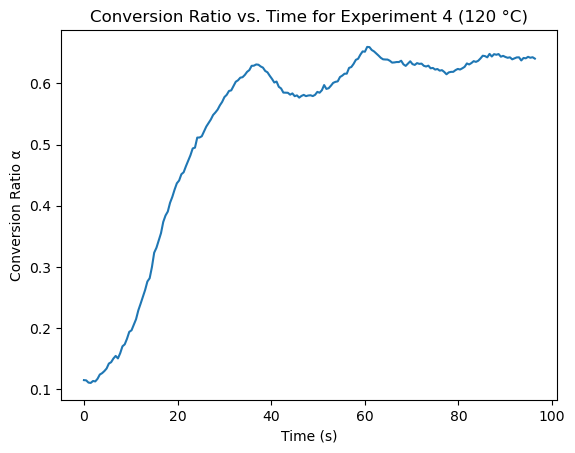

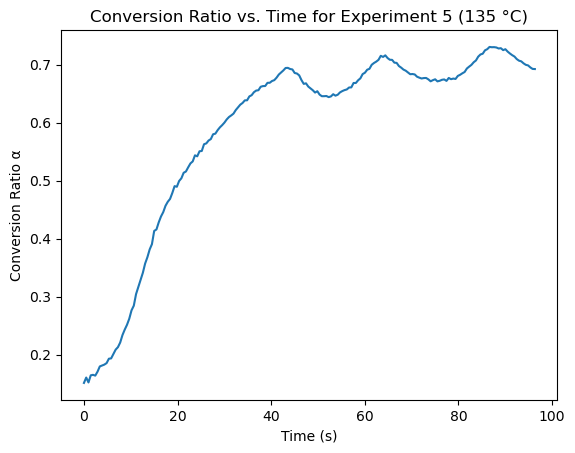

In [25]:
# Test alpha/q function
temps = ['75', '90', '105', '120', '135']
filepath = 'demo_data/batch_images/TOPA-1-075/TOPA-1-075_b0v0t0z0c0-32x0-512y0-512.png'
init_0, final_0 = load_init_image(filepath, init_channel='blue', final_channel='green')

for i, (temp, df) in enumerate(zip(temps, df_list)):
    exp_name = f'Experiment {i+1} ({temp} °C)'
    calculate_rxn_progress(df, init_0, final_0, exp_name, init_channel='blue', final_channel='green')

In [26]:
from scipy.optimize import curve_fit

def detect_equilibration(df, window=10, deriv_threshold=0.1):
    # Smooth first (when enough data exists), then differentiate
    if len(df['time']) > 2 * window:
        smooth_temps = df['temp'].rolling(window=window, center=True).mean().bfill().ffill()
    else:
        smooth_temps = df['temp']

    dt = np.diff(df['time'])
    dT = np.diff(smooth_temps)
    smooth_deriv = dT / dt

    for i in range(len(smooth_deriv)):
        if i + window <= len(smooth_deriv):
            window_slice = smooth_deriv[i:i+window]
            if np.max(np.abs(window_slice)) < deriv_threshold:
                return i + window // 2

    return None  # equilibration not detected

def sinusoidal_model(t, T_eq, A, omega, phi):
    """Sinusoidal oscillation model around equilibrium"""
    return T_eq + A * np.sin(omega * t + phi)

def analyze_temperature_series(df, target_temp=None):
    """
    Hybrid approach: detect equilibration, then fit sinusoidal model
    Returns equilibrium temperature and fit parameters
    """
    # Convert to numpy arrays if needed
    time = np.array(df['time'])
    temp = np.array(df['temp'])
    
    # Step 1: Detect equilibration point
    eq_idx = detect_equilibration(df)
    
    # Make sure we have enough data
    if eq_idx is None or eq_idx >= len(time) - 10:
        eq_idx = int(len(time) * 0.3)
    
    # Extract post-equilibration data
    time_eq = time[eq_idx:]
    temp_eq = temp[eq_idx:]
    
    # Adjust time to start from 0 for fitting
    time_fit = time_eq - time_eq[0]
    
    # Step 2: Fit sinusoidal model
    # Initial guesses
    T_eq_guess = np.mean(temp_eq)
    A_guess = (np.max(temp_eq) - np.min(temp_eq)) / 2
    
    # Estimate frequency from data using FFT
    if len(temp_eq) > 5:
        temp_centered = temp_eq - T_eq_guess
        fft = np.fft.fft(temp_centered)
        freqs = np.fft.fftfreq(len(temp_eq), d=np.mean(np.diff(time_fit)) if len(time_fit) > 1 else 1)
        
        # Find dominant frequency (excluding DC component)
        fft_mag = np.abs(fft[1:len(fft)//2])
        if len(fft_mag) > 0:
            peak_freq_idx = np.argmax(fft_mag) + 1
            omega_guess = 2 * np.pi * np.abs(freqs[peak_freq_idx])
        else:
            omega_guess = 0.1
    else:
        omega_guess = 0.1
    
    if omega_guess == 0 or not np.isfinite(omega_guess):
        omega_guess = 0.1
    
    phi_guess = 0
    
    try:
        # Fit the model
        popt, pcov = curve_fit(
            sinusoidal_model, 
            time_fit, 
            temp_eq,
            p0=[T_eq_guess, A_guess, omega_guess, phi_guess],
            maxfev=10000,
            bounds=([temp_eq.min()-10, 0, 0, -2*np.pi],
                    [temp_eq.max()+10, temp_eq.max()-temp_eq.min(), 10, 2*np.pi])
        )
        
        T_eq, A, omega, phi = popt
        
        return {
            'equilibrium_temp': T_eq,
            'amplitude': A,
            'omega': omega,
            'phase': phi,
            'eq_index': eq_idx,
            'fit_params': popt,
            'time_fit': time_fit,
            'temp_fit': temp_eq,
            'time_eq_start': time[eq_idx]
        }
    except Exception as e:
        print(f"  Fitting failed for target {target_temp}°C: {e}")
        print(f"  Using simple mean of post-equilibration data")
        # If fitting fails, just return the mean
        return {
            'equilibrium_temp': T_eq_guess,
            'amplitude': A_guess,
            'omega': omega_guess,
            'phase': 0,
            'eq_index': eq_idx,
            'fit_params': None,
            'time_fit': time_fit,
            'temp_fit': temp_eq,
            'time_eq_start': time[eq_idx]
        }

In [36]:
# Define exponential function for fitting
def exp_decay(t, a, b, c):
    """
    Exponential decay function: y = a * exp(-b * t) + c
    
    Parameters:
    - a: amplitude of decay
    - b: decay rate constant
    - c: equilibrium value (asymptote)
    
    Returns the equilibrium value 'c'
    """
    return a * np.exp(-b * t) + c

# Find equilibrated temperature and equilibrium constant for each experiment
def calc_equilibrium(df_list, temp_model='sinusoidal'):
    """
    Parameters
    ----------
    df_list : list of DataFrames
        Each DataFrame must contain 'time', 'temp', and 'q' columns.
    temp_model : str, optional
        Temperature fitting model to use. Either 'sinusoidal' (default) for the
        hybrid sinusoidal model, or 'exponential' for the exponential decay model.
    """
    if temp_model not in ('sinusoidal', 'exponential'):
        raise ValueError(f"temp_model must be 'sinusoidal' or 'exponential', got '{temp_model}'")

    eq_temps = []
    eq_consts = []
    
    for i, df in enumerate(df_list):
        print(f"Processing Experiment {i + 1}...")
        try:
            time = df['time'].values
            temp = df['temp'].values
            q = df['q'].values
            
            # --- Temperature fitting ---
            if temp_model == 'sinusoidal':
                temp_result = analyze_temperature_series(df, target_temp=None)
                equilibrium_temp = temp_result['equilibrium_temp']
                eq_index = temp_result['time_eq_start']
            else:  # exponential
                popt_temp, _ = curve_fit(exp_decay, time, temp,
                                         p0=[temp[0] - temp[-1], 0.1, temp[-1]],
                                         bounds=([-np.inf, 0, -np.inf], [np.inf, np.inf, np.inf]),
                                         maxfev=10000)
                equilibrium_temp = popt_temp[2]
                temp_result = None
                eq_index = df['time'].min()  # no induction period detected; shade nothing
            eq_temps.append(equilibrium_temp)
            
            # --- Reaction quotient: exponential decay ---
            popt_q, _ = curve_fit(exp_decay, time, q, 
                                  p0=[q[0] - q[-1], 0.1, q[-1]],
                                  bounds=([-np.inf, 0, -np.inf], [np.inf, np.inf, np.inf]),
                                  maxfev=10000)
            equilibrium_constant = popt_q[2]
            eq_consts.append(equilibrium_constant)
            
            print(f"  DataFrame {i + 1}: T_eq = {equilibrium_temp:.4f}, K_eq = {equilibrium_constant:.4f}")

            # --- Plotting ---
            figure, axes = plt.subplots(1, 2, figsize=(12, 5))

            # Temperature plot
            axes[0].plot(df['time'], df['temp'], color='tab:orange')
            axes[0].set_xlabel('Time (s)')
            axes[0].set_ylabel('Temperature (°C)')
            
            # Overlay fit curve if sinusoidal model was used and fit succeeded
            if temp_model == 'sinusoidal' and temp_result['fit_params'] is not None:
                t_plot = temp_result['time_fit']
                fit_curve = sinusoidal_model(t_plot, *temp_result['fit_params'])
                axes[0].plot(t_plot + eq_index, fit_curve, color='tab:red',
                             ls='--', lw=1.5, label='Sinusoidal fit')
            elif temp_model == 'exponential':
                fit_curve = exp_decay(time, *popt_temp)
                axes[0].plot(time, fit_curve, color='tab:red',
                             ls='--', lw=1.5, label='Exponential fit')
            axes[0].axhline(equilibrium_temp, color='tab:orange', ls='--', label='Equilibrated temperature')
            axes[0].legend()

            # Reaction quotient plot
            axes[1].plot(df['time'], df['q'], color='tab:purple')
            axes[1].set_xlabel('Time (s)')
            axes[1].set_ylabel('Reaction Quotient Q')
            q_fit_curve = exp_decay(time, *popt_q)
            axes[1].plot(time, q_fit_curve, color='tab:red',
                         ls='--', lw=1.5, label='Exponential fit')
            axes[1].axhline(equilibrium_constant, color='tab:purple', ls='--', alpha=0.6,
                            label='Equilibrium constant')
            axes[1].legend()

        except Exception as e:
            print(f"  DataFrame {i + 1}: Failed to fit - {str(e)}")
            eq_temps.append(np.nan)
            eq_consts.append(np.nan)

    print("\nProcessing complete!")
    print(f"Total experiments processed: {len(df_list)}")
    print(f"Results stored in eq_temps and eq_consts lists")
    return eq_temps, eq_consts

Processing Experiment 1...
  DataFrame 1: T_eq = 81.7313, K_eq = 0.5603
Processing Experiment 2...
  DataFrame 2: T_eq = 97.1641, K_eq = 0.9876
Processing Experiment 3...
  DataFrame 3: T_eq = 110.5522, K_eq = 1.3284
Processing Experiment 4...
  DataFrame 4: T_eq = 125.4642, K_eq = 1.8736
Processing Experiment 5...
  DataFrame 5: T_eq = 141.4736, K_eq = 2.5996

Processing complete!
Total experiments processed: 5
Results stored in eq_temps and eq_consts lists


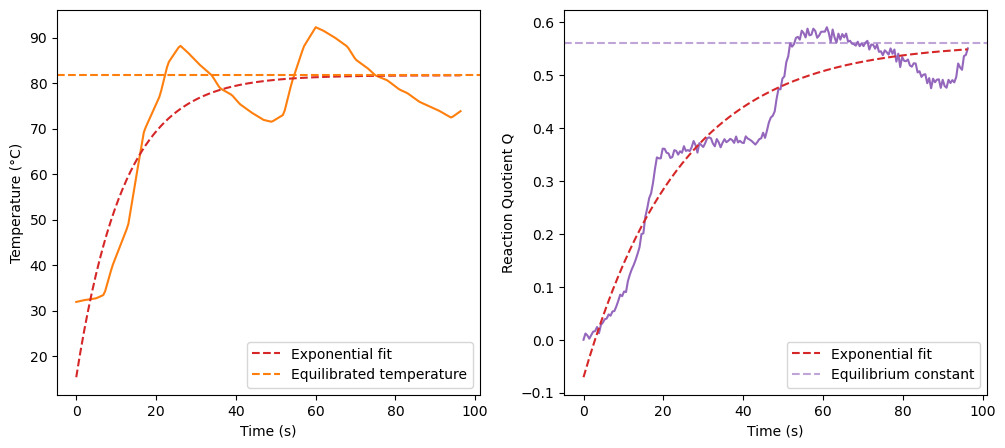

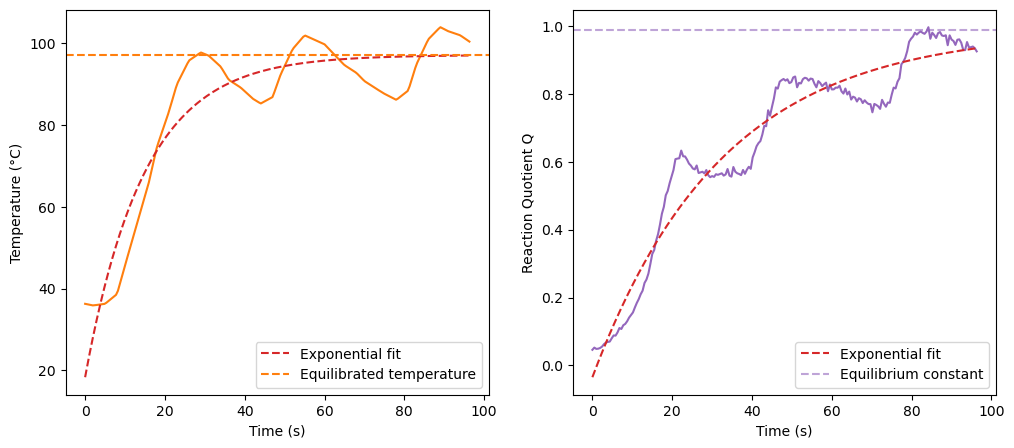

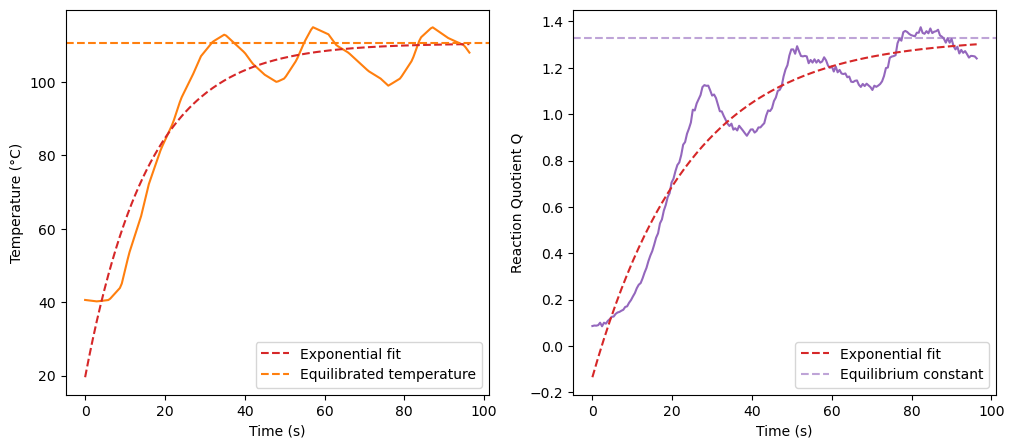

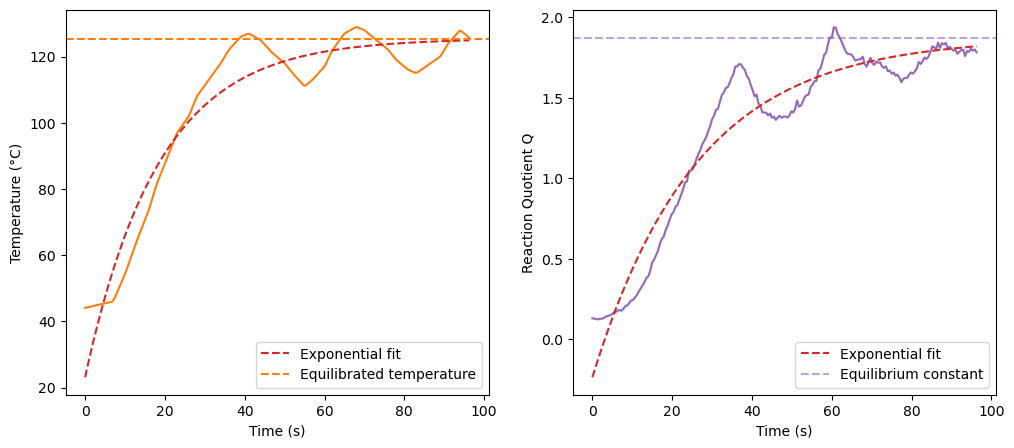

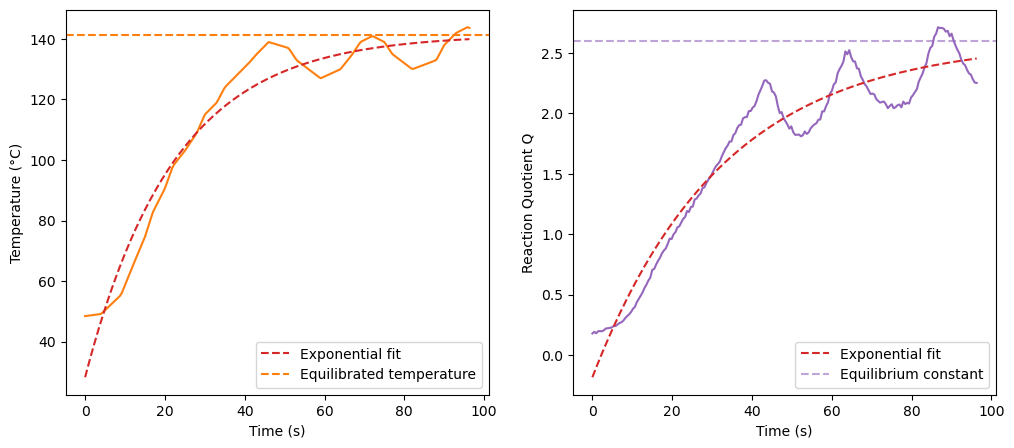

In [43]:
# Test equilibration function
eq_temps, eq_consts = calc_equilibrium(df_list, 'exponential')

In [40]:
# van't Hoff non-linear regression functions
def fit_ext_vanthoff(x_inv_T, x_lnT, y_lnK):
    """
    Fit the ln(T) form of the extended van't Hoff equation by OLS:

    ln K  =  -A/T  +  B·ln(T)  +  c

    which is linear in parameters [A, B, c], so we use numpy lstsq.

    OLS fit of  ln K = -A/T + B·ln(T) + c
    Design matrix columns: [-1/T, ln(T), 1]
    Returns (A, B, c, r_squared).

    R² is computed as 1 - SS_res / SS_tot, the standard coefficient of
    determination for the fit of ln(K) vs. the two predictors.

    Thermodynamic identities (ΔCp assumed constant):
    ΔCp   =  R · B
    ΔH(T) =  R · (A  +  B · T)       [from d(lnK)/d(1/T) = -ΔH/R]
    ΔS(T) =  R · (B·ln(T) + B + c)   [from ΔG = ΔH - TΔS = -RT·lnK]

    Reference: Clarke & Glew (1966) Trans. Faraday Soc. 62, 539–547;
        Grant & Higuchi (1984) Int. J. Pharmaceutics 18.

    """
    X = np.column_stack([-x_inv_T,             # coefficient A  (note sign: col = -1/T)
                          x_lnT,               # coefficient B
                          np.ones_like(x_inv_T)])  # constant c
    result = np.linalg.lstsq(X, y_lnK, rcond=None)
    A, B, c = result[0]
    y_pred  = X @ np.array([A, B, c])
    ss_res  = np.sum((y_lnK - y_pred) ** 2)
    ss_tot  = np.sum((y_lnK - y_lnK.mean()) ** 2)
    r2      = 1.0 - ss_res / ss_tot
    return A, B, c, r2

def thermodynamics_ext(A, B, c, T_ref):
    """
    Return ΔH, ΔS, ΔCp (all in J/mol or J/(mol·K)) at a reference temperature.
    """
    delta_Cp  = R * B
    delta_H   = R * (A + B * T_ref)   # J/mol  (use kJ/mol by /1000 if preferred)
    delta_S   = R * (B * np.log(T_ref) + B + c)  # J/(mol·K)
    return delta_H, delta_S, delta_Cp

In [39]:
# van't Hoff linear regression functions
def fit_lin_vanthoff(x_inv_T, y_lnK):
    """
    Fit the standard (linear) van't Hoff equation by OLS:
        ln K  =  -ΔH/R · (1/T)  +  ΔS/R
    which is linear in parameters [A, c], so we use numpy lstsq.
    OLS fit of  ln K = -A/T + c
    Design matrix columns: [-1/T, 1]
    Returns (A, c, r_squared).
    R² is computed as 1 - SS_res / SS_tot, the standard coefficient of
    determination for the fit of ln(K) vs. 1/T.
    Thermodynamic identities (ΔCp = 0 assumed):
        ΔH  =  R · A        [from d(lnK)/d(1/T) = -ΔH/R, constant with T]
        ΔS  =  R · c        [from ln K = -ΔH/RT + ΔS/R]
        ΔCp =  0            [implicit assumption of the linear model]
    Reference: van't Hoff (1884); Clarke & Glew (1966) Trans. Faraday Soc. 62, 539–547.
    """
    X = np.column_stack([-x_inv_T,                  # coefficient A  (note sign: col = -1/T)
                          np.ones_like(x_inv_T)])    # constant c
    result = np.linalg.lstsq(X, y_lnK, rcond=None)
    A, c = result[0]
    y_pred = X @ np.array([A, c])
    ss_res = np.sum((y_lnK - y_pred) ** 2)
    ss_tot = np.sum((y_lnK - y_lnK.mean()) ** 2)
    r2     = 1.0 - ss_res / ss_tot
    return A, c, r2

def thermodynamics_lin(A, c):
    """
    Return ΔH, ΔS, ΔCp (all in J/mol or J/(mol·K)).
    ΔCp is identically zero under the linear van't Hoff assumption.
    """
    delta_H  = R * A    # J/mol  (divide by 1000 for kJ/mol if preferred)
    delta_S  = R * c    # J/(mol·K)
    delta_Cp = 0.0      # linear model assumes temperature-independent ΔH
    return delta_H, delta_S, delta_Cp

In [47]:
# van't Hoff plot function
def vant_hoff_plot(eq_temps, eq_consts, temp_fit_model='exponential', vh_fit_model='nonlinear'):
    """
    Inputs:
    eq_temps: list of equilibrated temperatures calculated using calc_equilibrium function
    eq_consts: list of equilibrium constants calculated using calc_equilibrium function
    temp_fit_model: equilibration model for fitting temperature (default is exponential, can also use a hybrid sinusoidal model
        with induction period and then oscillation (better for const. temp, called using 'sinusoidal'))
    vh_fit_model: van't Hoff equation model, can either use linear van't Hoff equation or 3-variable truncation of extended van't Hoff
        (accounts for change in heat capacity during transformation)

    Outputs:
    van't Hoff plot
    van't Hoff regression parameters (linear or non-linear)
    Thermodynamic parameters (constant or functions of temp)
    """
    # Get parameters for van't Hoff plot
    vh_df = pd.DataFrame(list(zip(eq_temps, eq_consts)), columns=['temp', 'k_eq'])
    vh_df['temp_k'] = vh_df['temp'] + 273.15
    vh_df['1/T'] = 1/vh_df['temp_k']
    vh_df['ln(T)'] = np.log(vh_df['temp_k']) # need for non-linear expansion
    vh_df['ln(keq)'] = np.log(vh_df['k_eq'])

    # Plot van't Hoff plot
    plt.scatter(vh_df['1/T'], vh_df['ln(keq)'])
    plt.xlabel('1/T (1/K)')
    plt.ylabel('ln(K$_{eq}$)')

    # Add van't Hoff regression
    if vh_fit_model == 'nonlinear':
        A, B, c, r2 = fit_ext_vanthoff(vh_df['1/T'], vh_df['ln(T)'], vh_df['ln(keq)'])

        # Add regression to plot
        x_fit_inv = np.linspace(vh_df['1/T'].min(), vh_df['1/T'].max(), 200)
        T_fit     = 1.0 / x_fit_inv          # back to Kelvin
        y_fit     = -A * x_fit_inv + B * np.log(T_fit) + c
        plt.plot(x_fit_inv, y_fit, linestyle='-', linewidth=2, alpha=0.8)
        
    elif vh_fit_model == 'linear':
        A, c, r2 = fit_lin_vanthoff(vh_df['1/T'], vh_df['ln(keq)'])

        # Add regression to plot
        x_fit_inv = np.linspace(vh_df['1/T'].min(), vh_df['1/T'].max(), 200)
        T_fit     = 1.0 / x_fit_inv          # back to Kelvin
        y_fit     = -A * x_fit_inv + c
        plt.plot(x_fit_inv, y_fit, linestyle='-', linewidth=2, alpha=0.8)
        
    else: raise ValueError(f"vh_fit_model must be 'linear' or 'nonlinear', got '{vh_fit_model}'")
    plt.tight_layout()

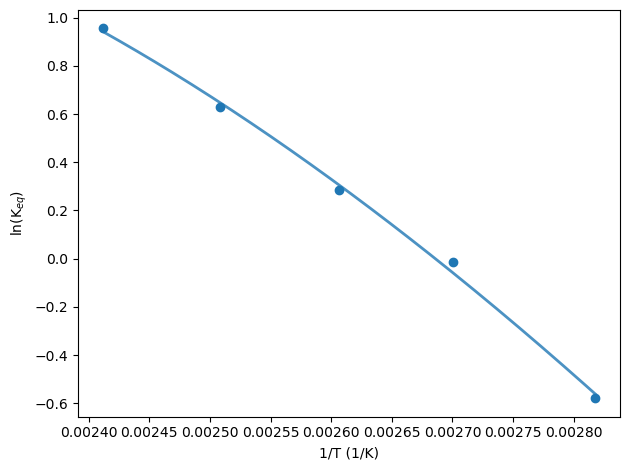

In [48]:
vant_hoff_plot(eq_temps, eq_consts, temp_fit_model='exponential', vh_fit_model='nonlinear')